# 02 · P300 classification and character selection

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Train a shrinkage LDA detector on real EEG, evaluate an unseen session, and implement row/column evidence accumulation with explicitly simulated flash metadata.

**Data:** Real BNCI2014-009 target detection; separate labeled speller simulation

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

Linear discriminant analysis models each class with a mean $\mu_k$ and a common covariance $\Sigma$. Its binary direction is $w=\Sigma^{-1}(\mu_1-\mu_0)$. Shrinkage uses $\Sigma_\lambda=(1-\lambda)\hat\Sigma+\lambda\alpha I$ to stabilize estimates when features are numerous or correlated. Scaling and covariance estimation belong inside the training pipeline.

ROC AUC measures ranking over thresholds: it is the probability a random target receives a higher score than a random non-target. Balanced accuracy is $(\mathrm{TPR}+\mathrm{TNR})/2$. Neither equals character accuracy. A row/column decoder adds flash evidence: $S_j=\sum_r s_{rj}$, then chooses the row and column with largest accumulated score. The mapping from flash to row/column must come from the experiment log; binary target labels cannot reconstruct it.

For $M$ equally likely commands, accuracy $P$ and decision duration $T$ seconds, the idealized information-transfer rate is $\mathrm{ITR}=\frac{60}{T}[\log_2 M+P\log_2P+(1-P)\log_2\frac{1-P}{M-1}]$. Its symmetric-error and independent-selection assumptions can fail; report actual selection time, correction time and a confusion matrix too.

## Load and separate sessions
Keep the final session completely outside fitting. All preprocessing settings are fixed in advance.

In [2]:
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300
dataset = BNCI2014_009()
paradigm = P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)
epochs, labels, metadata_p300 = paradigm.get_data(
    dataset=dataset, subjects=[1], return_epochs=True)
y = (np.asarray(labels) == 'Target').astype(int)
X = epochs.get_data(copy=True)  # volts; epochs x channels x samples
session = metadata_p300['session'].astype(str).to_numpy()
assert X.shape[0] == len(y) == len(session)
assert set(np.unique(y)) == {0, 1}
print(pd.crosstab(session, np.asarray(labels)))
print('Shape:', X.shape, 'sampling:', epochs.info['sfreq'], 'Hz')

train = session != sorted(np.unique(session))[-1]
test = ~train
windows = [(0.1,.25),(.25,.4),(.4,.6),(.6,.8)]
features = np.concatenate([X[:,:,(epochs.times>=a)&(epochs.times<b)].mean(-1)
                           for a,b in windows], axis=1)
assert set(session[train]).isdisjoint(set(session[test]))

/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


col_0  NonTarget  Target
row_0                   
0            480      96
1            480      96
2            480      96
Shape: (1728, 16, 103) sampling: 128.0 Hz


## Fit and evaluate
LDA priors reflect training prevalence. AUC uses continuous scores; threshold-based metrics use the default decision boundary, without test-set tuning.

Held-out session AUC: 0.8749131944444444
Balanced accuracy: 0.7333333333333334
              precision    recall  f1-score   support

  Non-target       0.91      0.95      0.93       480
      Target       0.66      0.52      0.58        96

    accuracy                           0.88       576
   macro avg       0.78      0.73      0.75       576
weighted avg       0.87      0.88      0.87       576



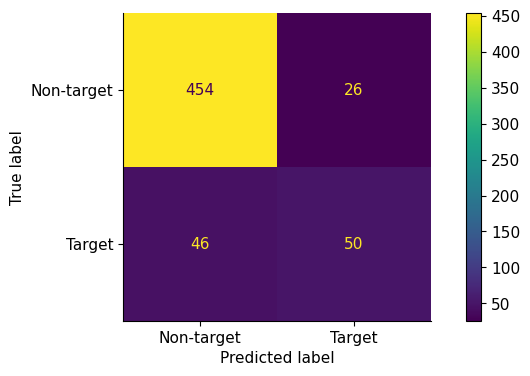

In [3]:
model = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
model.fit(features[train], y[train])
scores = model.decision_function(features[test])
pred = model.predict(features[test])
print('Held-out session AUC:', roc_auc_score(y[test], scores))
print('Balanced accuracy:', balanced_accuracy_score(y[test], pred))
print(classification_report(y[test], pred, target_names=['Non-target','Target'], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y[test], pred, display_labels=['Non-target','Target'])
plt.show()

## Decode characters with known flash identity
This separate simulation teaches aggregation only. Scores are simulated, not predictions on the real speller data; do not report its accuracy as experimental performance.

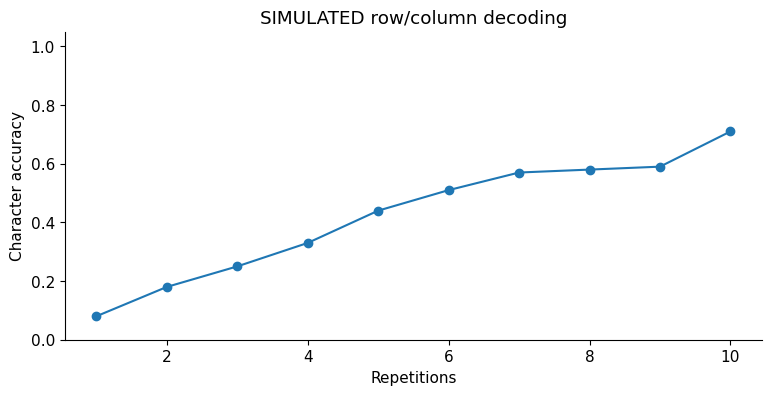

Example target: M decoded: S


In [4]:
alphabet = np.array(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')).reshape(6,6)
n_characters, repetitions = 100, 10
truth = rng.integers(0,36,n_characters)
flash_scores = rng.normal(0,1,(n_characters,repetitions,12))
for i, target in enumerate(truth):
    row, col = divmod(int(target),6)
    flash_scores[i,:,row] += 0.8
    flash_scores[i,:,6+col] += 0.8
accuracy = []
for r in range(1,repetitions+1):
    total = flash_scores[:,:r].sum(axis=1)
    selected = total[:,:6].argmax(1)*6 + total[:,6:].argmax(1)
    accuracy.append(np.mean(selected==truth))
fig, ax = plt.subplots()
ax.plot(range(1,repetitions+1),accuracy,'o-')
ax.set(xlabel='Repetitions',ylabel='Character accuracy',ylim=(0,1.05),title='SIMULATED row/column decoding')
plt.show()
print('Example target:', alphabet.flat[truth[0]], 'decoded:', alphabet.flat[selected[0]])

## Exercises and checks
1. Compare logistic regression with LDA using only training sessions for selection.
2. Why does the majority classifier have high accuracy but AUC 0.5?
3. Implement ITR for the simulated accuracy curve using 0.125 s per flash and 2 s overhead. Label the result simulated.
4. Write the additional metadata schema needed for real character decoding: character ID, repetition ID, flash group, target character and timestamps.

## Next steps and sources
[LDA](https://scikit-learn.org/stable/modules/lda_qda.html) · [P300 dataset](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.